In [52]:
"""
PROJECT TITLE: Oxymove (MOXY)
--------------------------------------------------
DESCRIPTION:
    This script aims to process raw torque data collected from the Biodex System 3 isokinetic dynamometer 
    during a concentric and eccentric task. The script will extract relevant metrics such as peak torque, time to peak torque, and total work done.
    The scipts plots the torque curves through time with some addons such as the mean, standard deviation skewness, kurtosis and events.

AUTHOR: Devaux Yann (EuroMov DHM / University of Montpellier)
CONTACT: yann.devaux@etu.umontpellier.fr
CREATED: 03/03/2026
VERSION: 0.0.1

INPUTS:
    - Compressed raw torque data (.tsv.gz)
    - Event markers file (.tsv)
    - Configuration file (.json)

OUTPUTS:
    - various plots and measures

LIBRARIES:
    Numpy, Pandas, Matplotlib, Shutil, Scipy, Gzip, Glob
"""

'\nPROJECT TITLE: Oxymove (MOXY)\n--------------------------------------------------\nDESCRIPTION:\n    This script aims to process raw torque data collected from the Biodex System 3 isokinetic dynamometer \n    during a concentric and eccentric task. The script will extract relevant metrics such as peak torque, time to peak torque, and total work done.\n    The scipts plots the torque curves through time with some addons such as the mean, standard deviation skewness, kurtosis and events.\n\nAUTHOR: Devaux Yann (EuroMov DHM / University of Montpellier)\nCONTACT: yann.devaux@etu.umontpellier.fr\nCREATED: 03/03/2026\nVERSION: 0.0.1\n\nINPUTS:\n    - Compressed raw torque data (.tsv.gz)\n    - Event markers file (.tsv)\n    - Configuration file (.json)\n\nOUTPUTS:\n    - various plots and measures\n\nLIBRARIES:\n    Numpy, Pandas, Matplotlib, Shutil, Scipy, Gzip, Glob\n'

In [53]:
#To make sure to have all the required libraries installed, you can run the following command in your terminal: 
#pip install gzip shutil pandas matplotlib numpy json scipy glob

In [54]:
import gzip
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy.stats import ttest_ind
import glob
from scipy.stats import ttest_1samp
from scipy.signal import find_peaks


In [55]:
subID='001'
sesID='001'
modality = "concentric"
torque_file_path = f"""\\Program Files\\DigiMove\\DigiMove\\DataAnalysisProject\\data\\MOXY-bids\\sub-{subID}\\ses-{sesID}\\beh\\sub-{subID}_ses-{sesID}_task-{modality}_recording-torque_physio.tsv.gz"""

In [56]:
#Extract .gz file
with gzip.open(torque_file_path, 'rb') as f_in:
    with open('file', 'wb') as f_out:
       shutil.copyfileobj(f_in, f_out)

In [57]:
#load the tsv file that was extracted
df = pd.read_csv(torque_file_path, sep='\t', header=None, names=['torque_Nm'])
#display the first few rows of the dataframe to check if it loaded correctly
print(df.head())
print(df.columns)

   torque_Nm
0  -0.049765
1   0.430278
2   0.526286
3   0.814312
4   0.526286
Index(['torque_Nm'], dtype='str')


In [58]:
#load the JSON file to extract the sampling frequency
frequency_file_path = f"""\\Program Files\\DigiMove\\DigiMove\\DataAnalysisProject\\data\\MOXY-bids\\sub-{subID}\\ses-{sesID}\\beh\\sub-{subID}_ses-{sesID}_task-{modality}_recording-torque_physio.json"""
with open(frequency_file_path, 'r') as f:
    frequency_data = json.load(f)
sampling_frequency = frequency_data['SamplingFrequency']

In [59]:
#load the event from the event.tsv file
events_filepath = f"""\\Program Files\\DigiMove\\DigiMove\\DataAnalysisProject\\data\\MOXY-bids\\sub-{subID}\\ses-{sesID}\\beh\\sub-{subID}_ses-{sesID}_task-{modality}_events.tsv"""
events = pd.read_csv(events_filepath, sep="\t")
print(events)


fs=sampling_frequency
df["time"] = np.arange(len(df))/fs


         onset  duration trial_type
0   918.723293         0        MVC
1   992.726686         0        MVC
2  1066.132068         0        MVC
3  1260.835733         0      Con50
4  1389.520155         0      Con50
5  1519.444601         0      Con50
6  1732.394609         0      Con30
7  1862.235053         0      Con30
8  1991.915494         0      Con30
9  2206.353531         0        MVC


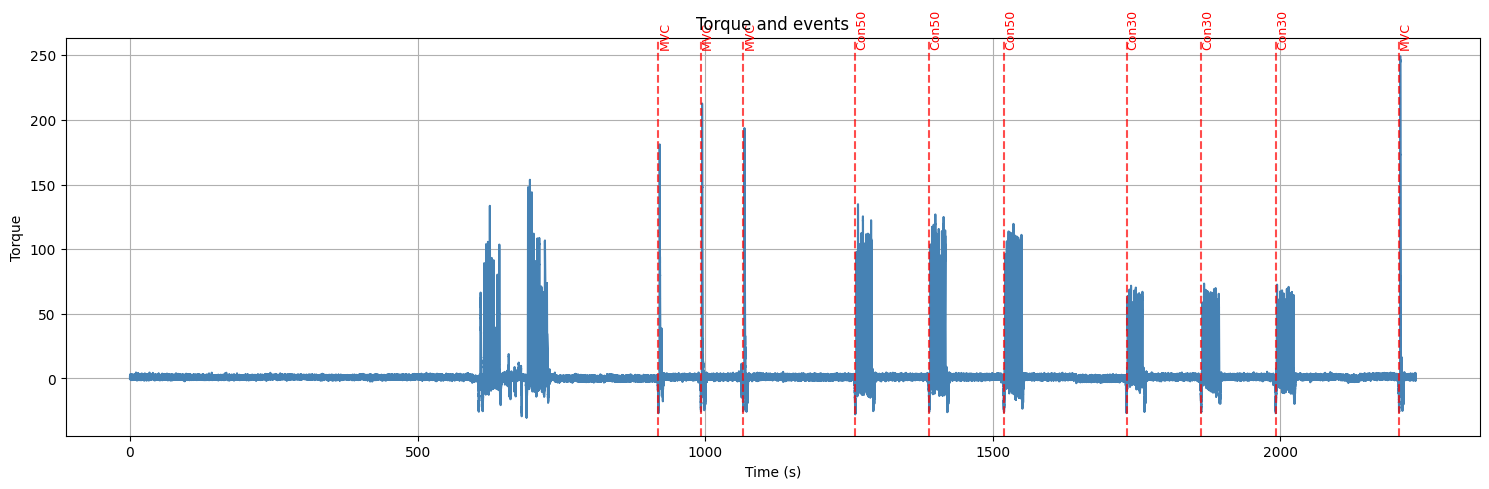

In [60]:
#visualize the data
plt.figure(figsize=(15, 5))

#torque
plt.plot(df["time"], df["torque_Nm"], label="Torque", color="steelblue")

#automatical verical lines for each event
for onset, label in zip(events["onset"], events["trial_type"]):
    plt.axvline(onset, color="red", linestyle="--", alpha=0.7)
    plt.text(onset, df["torque_Nm"].max()*1.02, label, rotation=90,
             verticalalignment="bottom", fontsize=9, color="red")

plt.xlabel("Time (s)")
plt.ylabel("Torque")
plt.title("Torque and events")
plt.grid(True)
plt.tight_layout()
plt.show()


Mean Torque: 3.460985687269715 Nm
Standard Deviation of Torque: 16.318759060519778 Nm
Skewness of Torque: 5.532165591180922
Kurtosis of Torque: 38.3847428505714


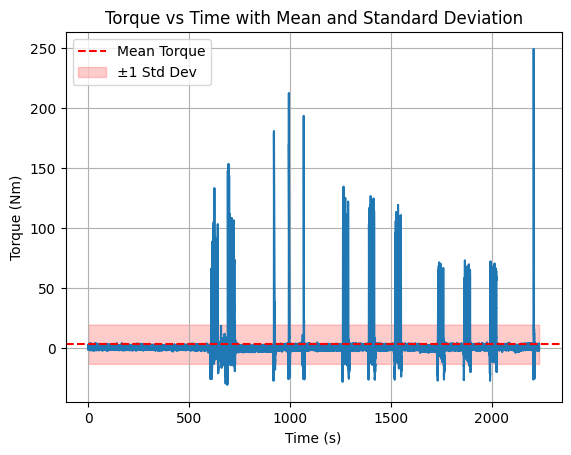

In [61]:
#extract the mean  
mean_torque = df['torque_Nm'].mean()
print(f'Mean Torque: {mean_torque} Nm')

#extract the strandard deviation
std_torque = df['torque_Nm'].std()
print(f'Standard Deviation of Torque: {std_torque} Nm')

#extract skewness
skewness_torque = df['torque_Nm'].skew()
print(f'Skewness of Torque: {skewness_torque}')

#extract kurtosis
kurtosis_torque = df['torque_Nm'].kurtosis()
print(f'Kurtosis of Torque: {kurtosis_torque}')

#and plot the linegraph 

plt.plot(df['time'], df['torque_Nm'])
plt.axhline(mean_torque, color='red', linestyle='--', label='Mean Torque')
plt.fill_between(df['time'], mean_torque - std_torque, mean_torque + std_torque, color='red', alpha=0.2, label='±1 Std Dev')
plt.xlabel('Time (s)')  
plt.ylabel('Torque (Nm)')
plt.title('Torque vs Time with Mean and Standard Deviation')
plt.legend()
plt.grid()
plt.show()



In [62]:
#This cell make sure that there is not a significant difference between the 3 first MVCs and the last one. 
#If there is, it would mean that the participant did not perform the task correctly and that the data is not usable.

#Compute the mean of the torque values for the 3 MVC
mvc_events = events[events['trial_type'] == 'MVC']

mvc_max_values = []

window = 6  #1 MVC duration (s)

for _, row in mvc_events.iterrows():
    t0 = row['onset']
    start = t0
    end = t0 + window

    segment = df[(df['time'] >= start) & (df['time'] <= end)]
    
    mvc_max = segment['torque_Nm'].max()
    mvc_max_values.append(float(mvc_max))

print("Max torque for each MVC:", mvc_max_values)

#Calculate the average of the max torque values across the 3 first MVCs
average_mvc_max = np.mean(mvc_max_values[0:3])
print(f'Average Max Torque across the 3 first MVCs: {average_mvc_max} Nm')

#Unpaired t-test between the average_mvc_max  and the last MVC to see if there is a significant difference


mvc_max_values = [1.9298302, 1.924031, 1.9249976, 1.9259641]

group_A = np.array(mvc_max_values[0:3])   # 3 premiers MVC
last = mvc_max_values[-1]                 # 4e MVC

t_stat, p_value = ttest_1samp(group_A, last)

print("T‑statistic:", t_stat)
print("P‑value:", p_value)

Max torque for each MVC: [181.0705, 212.70534, 193.69563, 249.42863]
Average Max Torque across the 3 first MVCs: 195.8238233333333 Nm
T‑statistic: 0.17959990709405163
P‑value: 0.8740155666594063


Con30 set 1: 10 peaks detected, mean = 66.393 Nm
Con30 set 2: 10 peaks detected, mean = 66.503 Nm
Con30 set 3: 10 peaks detected, mean = 66.854 Nm
Con50 set 1: 10 peaks detected, mean =  113.581 Nm
Con50 set 2: 10 peaks detected, mean =  114.229 Nm
Con50 set 3: 10 peaks detected, mean =  109.534 Nm


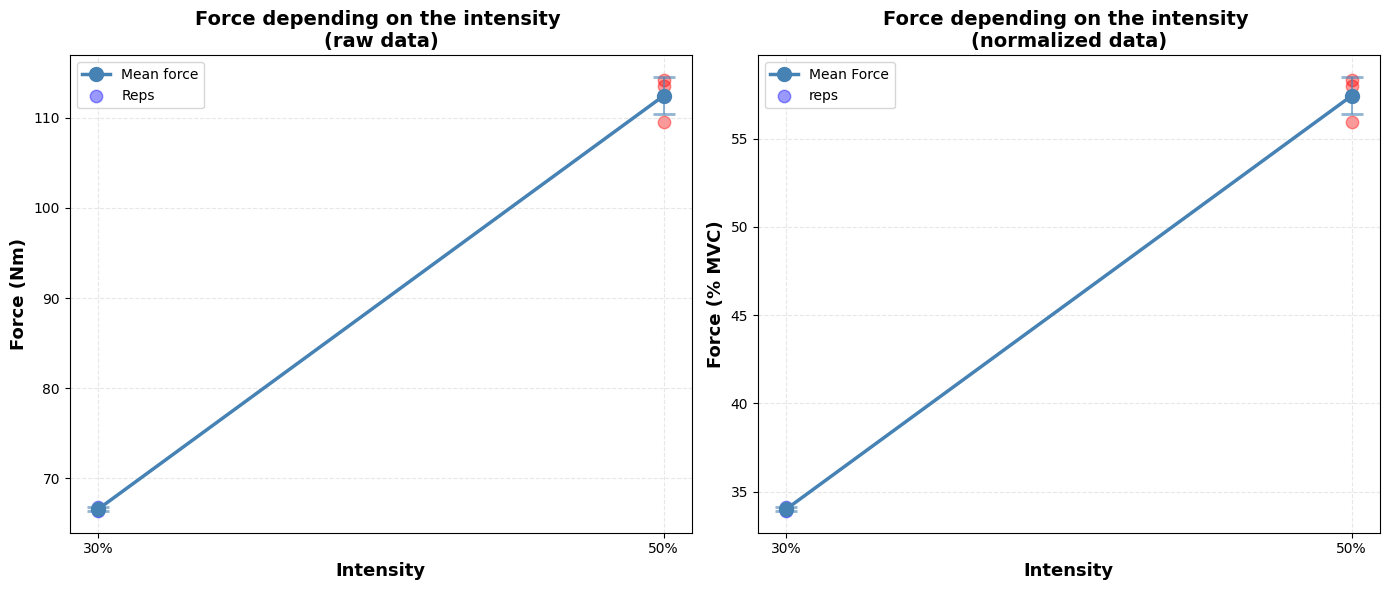


STATISTICS - Force as a function of intensity

Maximum Force (MVC): 195.824 Nm

INTENSITY 30% - Mean of force peaks per series
Total number of series: 3
Total number of detected peaks: 30

Mean of peaks per series (each series contains ~10-12 peaks):
  Series 1: 66.393 Nm (33.9% MVC)
  Series 2: 66.503 Nm (34.0% MVC)
  Series 3: 66.854 Nm (34.1% MVC)

→ OVERALL MEAN: 66.583 ± 0.196 Nm
→ NORMALIZED: 34.0 ± 0.1% MVC

INTENSITY 50% - Mean of force peaks per series
Total number of series: 3
Total number of detected peaks: 30

Mean of peaks per series (each series contains ~10-12 peaks):
  Series 1: 113.581 Nm (58.0% MVC)
  Series 2: 114.229 Nm (58.3% MVC)
  Series 3: 109.534 Nm (55.9% MVC)

→ OVERALL MEAN: 112.448 ± 2.077 Nm
→ NORMALIZED: 57.4 ± 1.1% MVC

--- Difference ---
  Δ Force: 45.865 Nm (68.9%)


In [63]:
#This cells shows the evolution of the deployed force between the 2 intensities (30% MVC and 50%)

# Extract every events, ou must replace 'Con30' with the intensity and mode that you want : Con30, Con50, Ecc30, Ecc50.
con30_events = events[events['trial_type'] == 'Con30']
con50_events = events[events['trial_type'] == 'Con50']

window = 30  # lenght of a typical set (20sec + "security" time)

#Function made to detect all the peaks in time series sample (made thanks to copilot)
def detect_peaks_in_segment(segment_data, sampling_freq=sampling_frequency, cycle_duration=2.0, height_threshold=0.3):
    """
    Detects peaks in a data segment by splitting it into fixed‑duration cycles.
    segment_data: force data series
    sampling_freq: sampling frequency (Hz)
    cycle_duration: duration of one back‑and‑forth cycle (seconds)
    height_threshold: minimum threshold to consider a peak (in Nm)
    """
    window_size = int(sampling_freq * cycle_duration) # Number of samples in one cycle
    
    peak_values = []
    peak_indices = []
    
    # Iterate through the segment in windows of size 'window_size'
    for i in range(0, len(segment_data), window_size):
        window = segment_data.iloc[i:i+window_size]
        
        if len(window) > 0:
            max_value = window.max()
            
            # Check if the maximum value in this window exceeds the height threshold
            if max_value >= height_threshold:
                # Find the index of the maximum value in this window
                max_idx_in_window = window.idxmax()
                peak_values.append(max_value)
                peak_indices.append(max_idx_in_window)
    
    return np.array(peak_values), peak_indices

# Extract and detect peaks for each Con30 series, and compute mean force
forces_30 = []  # Mean of every peak for each set
all_peaks_30 = []  # Every detected peak


for idx, row in con30_events.iterrows():
    t0 = row['onset']
    start = t0
    end = t0 + window
    segment = df[(df['time'] >= start) & (df['time'] <= end)]['torque_Nm']
    
    # Find peaks in the segment (2sec + 1 security second)
    peaks, peak_indices = detect_peaks_in_segment(segment, sampling_freq=fs, cycle_duration=3, height_threshold=0.3)
    
    if len(peaks) > 0:
        mean_peaks = np.mean(peaks)
        forces_30.append(mean_peaks)
        all_peaks_30.extend(peaks)
        print(f"Con30 set {len(forces_30)}: {len(peaks)} peaks detected, mean = {mean_peaks:.3f} Nm")
    else:
        print(f"Con30 set : No peak detected ")

# Extract and detect peaks for each Con30 series, and compute mean force
forces_50 = [] # Mean of every peak for each set
all_peaks_50 = []   # Every detected peak

for idx, row in con50_events.iterrows():
    t0 = row['onset']
    start = t0
    end = t0 + window
    segment = df[(df['time'] >= start) & (df['time'] <= end)]['torque_Nm']
    
    # Find peaks in the segment (2sec + 1 security second)
    peaks, peak_indices = detect_peaks_in_segment(segment, sampling_freq=fs, cycle_duration=3, height_threshold=0.5)
    
    if len(peaks) > 0:
        mean_peaks = np.mean(peaks)
        forces_50.append(mean_peaks)
        all_peaks_50.extend(peaks)
        print(f"Con50 set {len(forces_50)}: {len(peaks)} peaks detected, mean =  {mean_peaks:.3f} Nm")
    else:
        print(f"Con50 set : No peak detected ")


# Compute means
mean_force_30 = np.mean(forces_30)
mean_force_50 = np.mean(forces_50)
std_force_30 = np.std(forces_30)
std_force_50 = np.std(forces_50)

# Bring MVC to normalize
force_max = average_mvc_max

# Prepare data for graphs visualisation
intensites = [30, 50]
forces_brutes = [mean_force_30, mean_force_50]
forces_norm = [(mean_force_30 / force_max) * 100, (mean_force_50 / force_max) * 100]
std_brutes = [std_force_30, std_force_50]
std_norm = [(std_force_30 / force_max) * 100, (std_force_50 / force_max) * 100]

# Plot the figure with 2 subfigs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Raw graph
ax1.plot(intensites, forces_brutes, marker='o', markersize=10, linewidth=2.5, 
         color='steelblue', label='Mean force')
ax1.errorbar(intensites, forces_brutes, yerr=std_brutes, fmt='none', 
             ecolor='steelblue', capsize=8, capthick=2, alpha=0.6)

# Add individual points 
ax1.scatter([30]*len(forces_30), forces_30, alpha=0.4, s=80, color='blue', label='Reps')
ax1.scatter([50]*len(forces_50), forces_50, alpha=0.4, s=80, color='red')

ax1.set_xlabel('Intensity', fontsize=13, fontweight='bold')
ax1.set_ylabel('Force (Nm)', fontsize=13, fontweight='bold')
ax1.set_title('Force depending on the intensity \n(raw data)', fontsize=14, fontweight='bold')
ax1.set_xticks(intensites)
ax1.set_xticklabels(['30%', '50%'])
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3, linestyle='--')

# Normalized graph
ax2.plot(intensites, forces_norm, marker='o', markersize=10, linewidth=2.5, 
         color='steelblue', label='Mean Force')
ax2.errorbar(intensites, forces_norm, yerr=std_norm, fmt='none', 
             ecolor='steelblue', capsize=8, capthick=2, alpha=0.6)

# Add individual points (normalized)
forces_30_norm = [(f / force_max) * 100 for f in forces_30]
forces_50_norm = [(f / force_max) * 100 for f in forces_50]
ax2.scatter([30]*len(forces_30_norm), forces_30_norm, alpha=0.4, s=80, color='blue', label='reps')
ax2.scatter([50]*len(forces_50_norm), forces_50_norm, alpha=0.4, s=80, color='red')

ax2.set_xlabel('Intensity', fontsize=13, fontweight='bold')
ax2.set_ylabel('Force (% MVC)', fontsize=13, fontweight='bold')
ax2.set_title('Force depending on the intensity \n(normalized data)', fontsize=14, fontweight='bold')
ax2.set_xticks(intensites)
ax2.set_xticklabels(['30%', '50%'])
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Add some textual statistics to the console for a more detailed analysis of the results
print(f"\n{'='*70}")
print(f"STATISTICS - Force as a function of intensity")
print(f"{'='*70}")
print(f"\nMaximum Force (MVC): {force_max:.3f} Nm")

print(f"\n{'='*70}")
print(f"INTENSITY 30% - Mean of force peaks per series")
print(f"{'='*70}")
print(f"Total number of series: {len(forces_30)}")
print(f"Total number of detected peaks: {len(all_peaks_30)}")
print(f"\nMean of peaks per series (each series contains ~10-12 peaks):")
for i, force in enumerate(forces_30, 1):
    print(f"  Series {i}: {force:.3f} Nm ({(force/force_max)*100:.1f}% MVC)")
print(f"\n→ OVERALL MEAN: {mean_force_30:.3f} ± {std_force_30:.3f} Nm")
print(f"→ NORMALIZED: {(mean_force_30/force_max)*100:.1f} ± {(std_force_30/force_max)*100:.1f}% MVC")

print(f"\n{'='*70}")
print(f"INTENSITY 50% - Mean of force peaks per series")
print(f"{'='*70}")
print(f"Total number of series: {len(forces_50)}")
print(f"Total number of detected peaks: {len(all_peaks_50)}")
print(f"\nMean of peaks per series (each series contains ~10-12 peaks):")
for i, force in enumerate(forces_50, 1):
    print(f"  Series {i}: {force:.3f} Nm ({(force/force_max)*100:.1f}% MVC)")
print(f"\n→ OVERALL MEAN: {mean_force_50:.3f} ± {std_force_50:.3f} Nm")
print(f"→ NORMALIZED: {(mean_force_50/force_max)*100:.1f} ± {(std_force_50/force_max)*100:.1f}% MVC")

print(f"\n--- Difference ---")
print(f"  Δ Force: {mean_force_50 - mean_force_30:.3f} Nm ({((mean_force_50-mean_force_30)/mean_force_30)*100:.1f}%)")
print(f"{'='*60}")


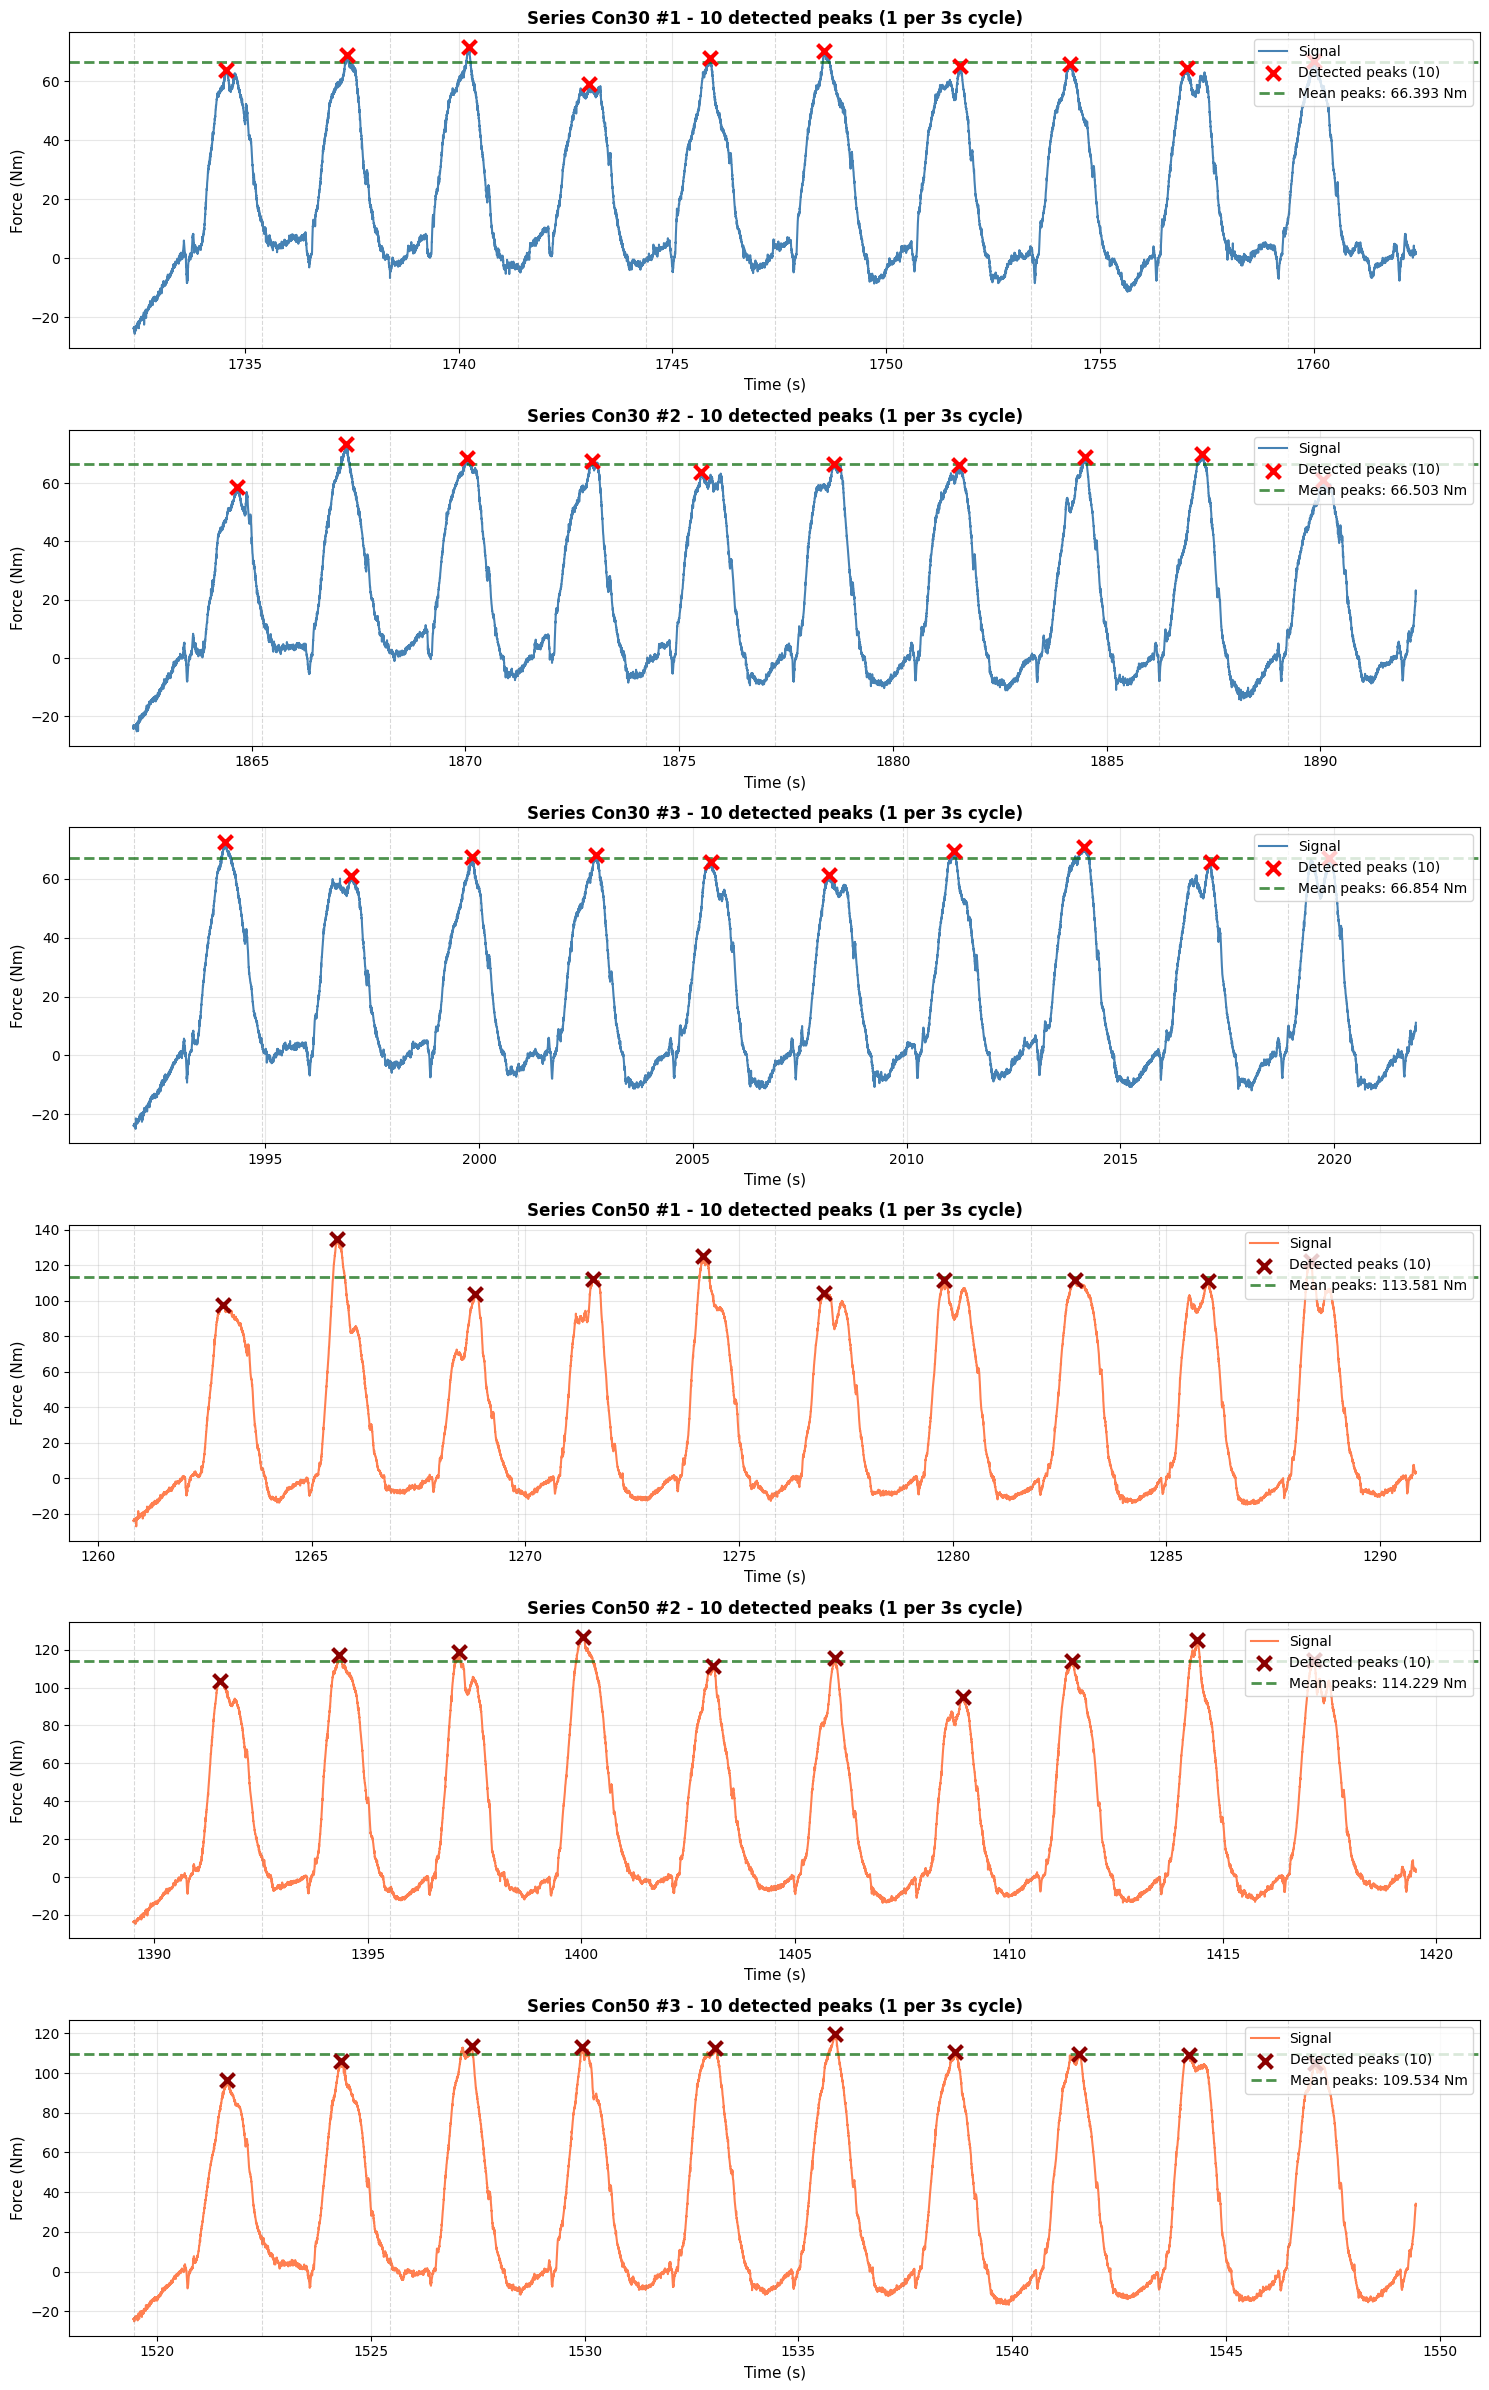

In [64]:
#This cell helps to visualize the detection of the peaks. If the set has been done correctly, we should see 10 peaks for each set.

# Visualization of peak detection
# This graph shows where peaks are detected in each series

fig, axes = plt.subplots(len(con30_events) + len(con50_events), 1, 
                         figsize=(15, 4 * (len(con30_events) + len(con50_events))))

plot_idx = 0

# Visualize Con30
for serie_idx, (idx, row) in enumerate(con30_events.iterrows(), 1):
    t0 = row['onset']
    start = t0
    end = t0 + window
    
    segment_df = df[(df['time'] >= start) & (df['time'] <= end)]
    segment_data = segment_df['torque_Nm'].reset_index(drop=True)
    time_segment = segment_df['time'].reset_index(drop=True)
    
    # Detect peaks (3-second cycles with maximum per cycle)
    peak_values, peak_indices = detect_peaks_in_segment(segment_data, sampling_freq=fs, cycle_duration=3, height_threshold=0.3)
    
    # Plot the curve
    axes[plot_idx].plot(time_segment, segment_data, linewidth=1.5, color='steelblue', label='Signal')
    
    # Mark the 3-second windows
    window_size = int(fs * 3)
    for i in range(0, len(segment_data), window_size):
        t_window = time_segment.iloc[i] if i < len(time_segment) else time_segment.iloc[-1]
        axes[plot_idx].axvline(t_window, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
    
    # Mark detected peaks
    if len(peak_values) > 0:
        peak_times = time_segment.iloc[peak_indices]
        axes[plot_idx].scatter(peak_times, peak_values, color='red', s=100, 
                              zorder=5, marker='x', linewidths=3, label=f'Detected peaks ({len(peak_values)})')
        
        # Add a horizontal line for the mean of peaks
        mean_peak = np.mean(peak_values)
        axes[plot_idx].axhline(mean_peak, color='darkgreen', linestyle='--', 
                              linewidth=2, alpha=0.7, label=f'Mean peaks: {mean_peak:.3f} Nm')
    
    axes[plot_idx].set_xlabel('Time (s)', fontsize=11)
    axes[plot_idx].set_ylabel('Force (Nm)', fontsize=11)
    axes[plot_idx].set_title(f'Series Con30 #{serie_idx} - {len(peak_values)} detected peaks (1 per 3s cycle)', 
                            fontsize=12, fontweight='bold')
    axes[plot_idx].legend(loc='upper right')
    axes[plot_idx].grid(True, alpha=0.3)
    
    plot_idx += 1

# Visualize Con50
for serie_idx, (idx, row) in enumerate(con50_events.iterrows(), 1):
    t0 = row['onset']
    start = t0
    end = t0 + window
    
    segment_df = df[(df['time'] >= start) & (df['time'] <= end)]
    segment_data = segment_df['torque_Nm'].reset_index(drop=True)
    time_segment = segment_df['time'].reset_index(drop=True)
    
    # Detect peaks (3-second cycles with maximum per cycle)
    peak_values, peak_indices = detect_peaks_in_segment(segment_data, sampling_freq=fs, cycle_duration=3, height_threshold=0.5)
    
    # Plot the curve
    axes[plot_idx].plot(time_segment, segment_data, linewidth=1.5, color='coral', label='Signal')
    
    # Mark the 3-second windows
    window_size = int(fs * 3)
    for i in range(0, len(segment_data), window_size):
        t_window = time_segment.iloc[i] if i < len(time_segment) else time_segment.iloc[-1]
        axes[plot_idx].axvline(t_window, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
    
    # Mark detected peaks
    if len(peak_values) > 0:
        peak_times = time_segment.iloc[peak_indices]
        axes[plot_idx].scatter(peak_times, peak_values, color='darkred', s=100, 
                              zorder=5, marker='x', linewidths=3, label=f'Detected peaks ({len(peak_values)})')
        
        # Add a horizontal line for the mean of peaks
        mean_peak = np.mean(peak_values)
        axes[plot_idx].axhline(mean_peak, color='darkgreen', linestyle='--', 
                              linewidth=2, alpha=0.7, label=f'Mean peaks: {mean_peak:.3f} Nm')
    
    axes[plot_idx].set_xlabel('Time (s)', fontsize=11)
    axes[plot_idx].set_ylabel('Force (Nm)', fontsize=11)
    axes[plot_idx].set_title(f'Series Con50 #{serie_idx} - {len(peak_values)} detected peaks (1 per 3s cycle)', 
                            fontsize=12, fontweight='bold')
    axes[plot_idx].legend(loc='upper right')
    axes[plot_idx].grid(True, alpha=0.3)
    
    plot_idx += 1

plt.tight_layout()
plt.show()

In [65]:
#This cell do the 2 previous one for all subjects and sessions, and save the results in a csv file.

import os
import glob

# Base directory
base_dir = r"C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids"

# Find all subjects
subjects = sorted([d for d in os.listdir(base_dir) if d.startswith('sub-')])

# Initialize results list
results = []

# Loop through each subject
for sub_id in subjects:
    sub_folder = os.path.join(base_dir, sub_id)
    
    # Find all sessions for this subject
    sessions = sorted([d for d in os.listdir(sub_folder) if d.startswith('ses-')])
    
    for ses_id in sessions:
        # Check for both task types (concentric and eccentric)
        for task_type in ['concentric', 'eccentric']:
            # Define file paths
            torque_file = os.path.join(sub_folder, ses_id, 'beh', 
                                      f"{sub_id}_{ses_id}_task-{task_type}_recording-torque_physio.tsv.gz")
            events_file = os.path.join(sub_folder, ses_id, 'beh',
                                      f"{sub_id}_{ses_id}_task-{task_type}_events.tsv")
            json_file = os.path.join(sub_folder, ses_id, 'beh',
                                    f"{sub_id}_{ses_id}_task-{task_type}_recording-torque_physio.json")
            
            # Check if files exist
            if not os.path.exists(torque_file) or not os.path.exists(events_file):
                continue
                
            print(f"\nProcessing {sub_id} - {ses_id} - {task_type}...")
            
            try:
                # Load data
                df_temp = pd.read_csv(torque_file, sep='\t', header=None, names=['torque_Nm'])
                events_temp = pd.read_csv(events_file, sep="\t")
                
                # Load sampling frequency
                with open(json_file, 'r') as f:
                    frequency_data_temp = json.load(f)
                fs_temp = frequency_data_temp['SamplingFrequency']
                
                # Add time column
                df_temp["time"] = np.arange(len(df_temp)) / fs_temp
                
                # Calculate MVC for normalization
                mvc_events_temp = events_temp[events_temp['trial_type'] == 'MVC']
                mvc_max_values_temp = []
                window_mvc = 6
                
                for _, row in mvc_events_temp.iterrows():
                    start = row['onset']
                    end = start + window_mvc
                    segment = df_temp[(df_temp['time'] >= start) & (df_temp['time'] <= end)]
                    mvc_max = segment['torque_Nm'].max()
                    mvc_max_values_temp.append(float(mvc_max))
                
                if len(mvc_max_values_temp) >= 3:
                    average_mvc = np.mean(mvc_max_values_temp[0:3])
                else:
                    average_mvc = np.mean(mvc_max_values_temp) if len(mvc_max_values_temp) > 0 else np.nan
                
                # Define contraction modes based on task type
                if task_type == 'concentric':
                    modes = [('Con30', 0.3), ('Con50', 0.5)]
                else:  # eccentric
                    modes = [('Ecc30', 0.3), ('Ecc50', 0.5)]
                
                # Process each contraction mode
                for mode_name, height_threshold in modes:
                    mode_events = events_temp[events_temp['trial_type'] == mode_name]
                    
                    if len(mode_events) == 0:
                        continue
                    
                    forces_mode = []
                    window_contraction = 30
                    
                    # Process each series
                    for idx, row in mode_events.iterrows():
                        t0 = row['onset']
                        start = t0
                        end = t0 + window_contraction
                        segment = df_temp[(df_temp['time'] >= start) & (df_temp['time'] <= end)]['torque_Nm']
                        
                        # Detect peaks
                        peaks, _ = detect_peaks_in_segment(segment, sampling_freq=fs_temp, 
                                                           cycle_duration=3, 
                                                           height_threshold=height_threshold)
                        
                        if len(peaks) > 0:
                            mean_peaks = np.mean(peaks)
                            forces_mode.append(mean_peaks)
                    
                    # Calculate statistics for this mode
                    if len(forces_mode) > 0:
                        mean_force = np.mean(forces_mode)
                        std_force = np.std(forces_mode)
                        mean_force_normalized = (mean_force / average_mvc) * 100 if not np.isnan(average_mvc) else np.nan
                        std_force_normalized = (std_force / average_mvc) * 100 if not np.isnan(average_mvc) else np.nan
                        
                        # Add results
                        results.append({
                            'Subject': sub_id,
                            'Session': ses_id,
                            'Task': task_type,
                            'Contraction_Mode': mode_name,
                            'Mean_Force_Nm': mean_force,
                            'Std_Force_Nm': std_force,
                            'Mean_Force_Percent_MVC': mean_force_normalized,
                            'Std_Force_Percent_MVC': std_force_normalized,
                            'MVC_Nm': average_mvc,
                            'Number_of_Series': len(forces_mode),
                        })
                        
                        print(f"  {mode_name}: Mean = {mean_force:.2f} Nm ({mean_force_normalized:.1f}% MVC), N_series = {len(forces_mode)}")
            
            except Exception as e:
                print(f"  Error processing {sub_id} - {ses_id} - {task_type}: {str(e)}")
                continue

# Create DataFrame with results
df_results = pd.DataFrame(results)

# Save to CSV
output_file = os.path.join(r"C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\Analysis_Results", "torque_analysis_results.csv")
df_results.to_csv(output_file, index=False, sep=';', decimal=',')

print(f"\n{'='*70}")
print(f"Analysis complete!")
print(f"Results saved to: {output_file}")
print(f"Total rows: {len(df_results)}")
print(f"{'='*70}")

# Display summary
print("\nSummary of results:")
print(df_results.to_string())



Processing sub-001 - ses-001 - concentric...
  Con30: Mean = 66.58 Nm (34.0% MVC), N_series = 3
  Con50: Mean = 112.45 Nm (57.4% MVC), N_series = 3

Processing sub-001 - ses-002 - eccentric...
  Ecc30: Mean = 109.11 Nm (31.0% MVC), N_series = 3
  Ecc50: Mean = 178.27 Nm (50.7% MVC), N_series = 3

Processing sub-002 - ses-001 - eccentric...
  Ecc30: Mean = 107.60 Nm (33.9% MVC), N_series = 3
  Ecc50: Mean = 143.25 Nm (45.1% MVC), N_series = 2

Processing sub-002 - ses-002 - concentric...
  Con30: Mean = 71.78 Nm (37.3% MVC), N_series = 3
  Con50: Mean = 110.93 Nm (57.6% MVC), N_series = 3

Processing sub-003 - ses-001 - eccentric...
  Ecc30: Mean = 66.84 Nm (32.5% MVC), N_series = 3
  Ecc50: Mean = 113.01 Nm (54.9% MVC), N_series = 3

Processing sub-003 - ses-002 - concentric...
  Con30: Mean = 48.27 Nm (34.2% MVC), N_series = 3
  Con50: Mean = 80.13 Nm (56.7% MVC), N_series = 3

Analysis complete!
Results saved to: C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\Analysis_Result